# **CMSE 381 Final Project**

## Group Members: Alex Chen and Kevin Chiang

## Section 01

## Date: April 24, 2026

## **Project Title:** 

## Predicting Student Academic Performance Using Behavioral and Demographic Data

## **Background and Motivation**

Student academic performance is influenced by a combination of behavioral, environmental, and socioeconomic factors. Understanding these relationships is important for improving educational outcomes and identifying at-risk students early.

## **Research Questions**

* Which factors most strongly influence exam scores?
* Can we accurately predict exam scores using regression models?
* Can we classify students into performance categories (high vs. low)?
* Do behavioral factors (study hours and sleep) have a stronger impact than demographic factors?

## **Methodology**

We approached this problem in four main steps:

* Data preprocessing
* Regression modeling (predict Exam_Score)
* Classification modeling (high vs low performance)
* Additional method: Feature importance + cross-validation

Model performance for regression was evaluated using Root Mean Squared Error (RMSE), while classification performance was evaluated using accuracy, precision, and recall.

## **Data**

The dataset contains student-level data with variables such as:

* Hours_Studied: weekly study hours
* Attendance: % attendance
* Sleep_Hours
* Previous_Scores
* Motivation_Level
* Family_Income
* Exam_Score (target)

### *Import Libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
plt.style.use('default')
sns.set_theme()

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

### *Load Data*

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### *Preprocessing*

Categorical variables were converted using one-hot encoding.

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("Exam_Score", axis=1)
y = df_encoded["Exam_Score"]

## **Models for Regression**

### Goal:

* Predict Exam_Score


### Models Used:

* Linear Regression
* Random Forest Regressor

### Why:

* Linear Regression (sklearn): Used to measure overall prediction error (RMSE) and evaluate how well the model generalizes to unseen data.
* OLS Regression (statsmodels): Used to examine the individual effect of each feature on exam scores, including coefficient estimates and statistical significance.
* Random Forest Regressor: Used to capture any nonlinear relationships that Linear Regression might miss.

### *Train/Test Split*

In [4]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.2, random_state=42)

### *Linear Regression*

In [5]:
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
y_pred_lr = lr.predict(X_test_reg)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 1.8046317813990214


In [6]:
X = df[['Hours_Studied', 'Attendance', 'Sleep_Hours']]
y = df['Exam_Score']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     2599.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:08:39   Log-Likelihood:                -15775.
No. Observations:                6607   AIC:                         3.156e+04
Df Residuals:                    6603   BIC:                         3.158e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            45.8436      0.297    154.101

### Interpretation

The OLS results show that the model explains about $54.1$% of the variation in exam scores ($R^2 = 0.541$). This means a little over half of the differences in students’ exam scores can be explained by the features we included.

The coefficient for Hours Studied is about $0.29$ and is highly significant ($p < 0.001$). This means that, on average, each extra hour of studying is linked to about a $0.29$-point increase in exam score, assuming all other factors stay the same.

Attendance also has a positive and significant effect (about $0.20$ per unit increase), meaning students who attend more classes tend to score higher.

Sleep Hours, however, is not statistically significant ($p = 0.129$), so we do not have strong evidence that it affects exam scores in this model.

Overall, the results suggest that study habits like hours studied and attendance are the main factors related to better exam performance, while sleep does not show a clear effect in this dataset.

### *Random Forest Regression*

In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf.predict(X_test_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 2.2306909575869565


## **Models for Classification**

### Goal:

Classify students into:

* High performance (Exam_Score $\geq 70$)
* Low performance ($<70$)

### *Create Target*

In [8]:
df_encoded["High_Performance"] = (df_encoded["Exam_Score"] >= 70).astype(int)

X_class = df_encoded.drop(["Exam_Score", "High_Performance"], axis=1)
y_class = df_encoded["High_Performance"]

### *Logistic Regression*

In [9]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf, y_train_clf)

y_pred = log_model.predict(X_test_clf)

print("Accuracy:", accuracy_score(y_test_clf, y_pred))
print(classification_report(y_test_clf, y_pred))

Accuracy: 0.9863842662632375
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       974
           1       0.99      0.96      0.97       348

    accuracy                           0.99      1322
   macro avg       0.99      0.98      0.98      1322
weighted avg       0.99      0.99      0.99      1322



### *Random Forest Classifier*

In [10]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf = rf_clf.predict(X_test_clf)

print("RF Accuracy:", accuracy_score(y_test_clf, y_pred_rf))

RF Accuracy: 0.9198184568835098


## **Other Methods Used**

### *K-Fold Cross Validation*

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_cv = df_encoded.drop("Exam_Score", axis=1)
y_cv = df_encoded["Exam_Score"]
scores = cross_val_score(rf, X_train_reg, y_train_reg, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)

print("CV RMSE:", rmse_scores.mean())

CV RMSE: 2.5068426408417133


### *Feature Importance*

In [12]:
importances = rf.feature_importances_
features = X_train_reg.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)
print(feat_df.head())

             Feature  Importance
1         Attendance    0.380579
0      Hours_Studied    0.242559
3    Previous_Scores    0.092155
4  Tutoring_Sessions    0.037904
5  Physical_Activity    0.027719


## **Results**

### Regression Results

#### What are we trying to do?

We want to predict students’ Exam_Score using regression models and evaluate how accurately different models perform.

#### Model Performance

* Linear Regression RMSE: $1.80$
* Random Forest RMSE: $2.23$
* Cross-Validation RMSE (RF): $2.51$

## **Visualizations**

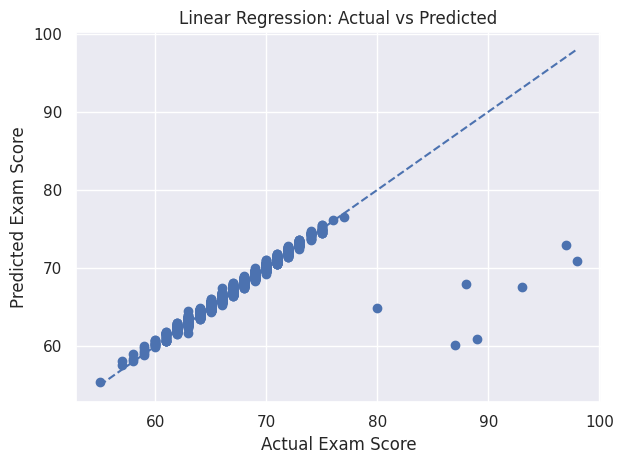

In [13]:
plt.figure()
plt.scatter(y_test_reg, y_pred_lr)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         linestyle='--')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

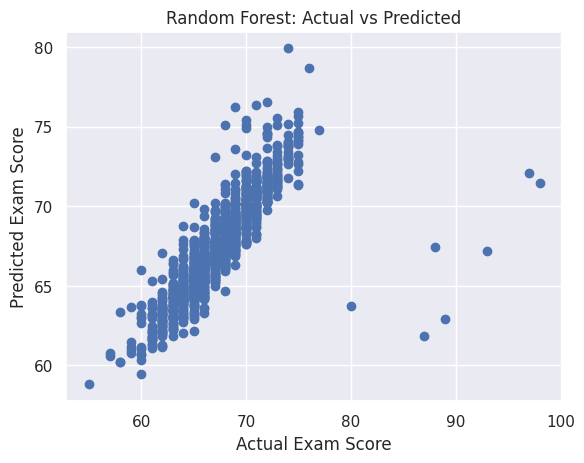

In [14]:
plt.figure()
plt.scatter(y_test_reg, y_pred_rf_reg)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

### **Interpretation**

Linear Regression performs better than Random Forest, with a lower RMSE ($1.80$ vs. $2.23$). This suggests that the relationship between the input features and exam scores is mostly linear. The higher cross-validation RMSE for Random Forest (around $2.51$) also shows that it does not generalize as well, meaning the extra complexity of that model does not improve performance for this dataset. Note that cross-validation was only performed on the Random Forest model. The Linear Regression RMSE of $1.80$ comes from a single train/test split, so a direct CV-based comparison between the two models was not made.

## **Classification Results**

### What are we trying to do?

We classify students into:
* High Performance (Exam_Score $\geq 70$)
* Low Performance (Exam_Score $< 70$)

### Model Performance

Logistic Regression:
* Accuracy: $98.64$%
* Very high precision and recall for both classes

Random Forest Classifier:
* Accuracy: $91.98$%

### Interpretation

Logistic Regression outperforms Random Forest, with an accuracy of about $98.64$% compared to $91.98%$. This suggests the data can be separated reasonably well using a simple linear boundary. The high recall values ($0.96–0.99$) show that the model correctly identifies most students in both groups, which means the data has strong patterns.

It is also worth noting that the test set contains $974$ low performers and $348$ high performers, a roughly $74/26$ split. This imbalance can partially inflate the overall accuracy, so precision and recall for the minority class are more informative metrics here.

The very high accuracy could also mean the model is overfitting, or that the dataset has a very clear structure. To confirm, it would be a good idea to test the model on new, unseen data.

## **Other Results (Feature Importance)**

| Feature           | Importance |
| ----------------- | ---------- |
| Attendance        | 0.381      |
| Hours_Studied     | 0.243      |
| Previous_Scores   | 0.092      |
| Tutoring_Sessions | 0.038      |
| Physical_Activity | 0.028      |


Attendance, Hours Studied, and Previous Scores have the biggest impact on the model.

This aligns expectations as students who did well before and spend more time studying are more likely to get higher exam scores. Attendance also matters because regular attendance is associated with higher exam scores, likely reflecting greater engagement with the material.

Overall, behavior-related factors seem to matter more than demographic variables in this dataset.

### *Visualization*

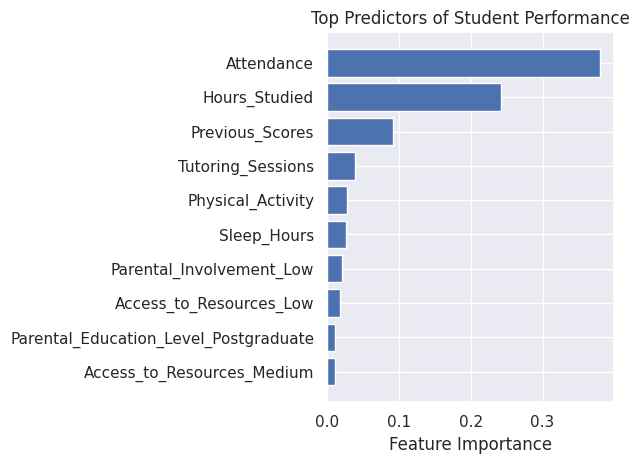

In [15]:
top_features = feat_df.nlargest(10, "Importance")
plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")

plt.title("Top Predictors of Student Performance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

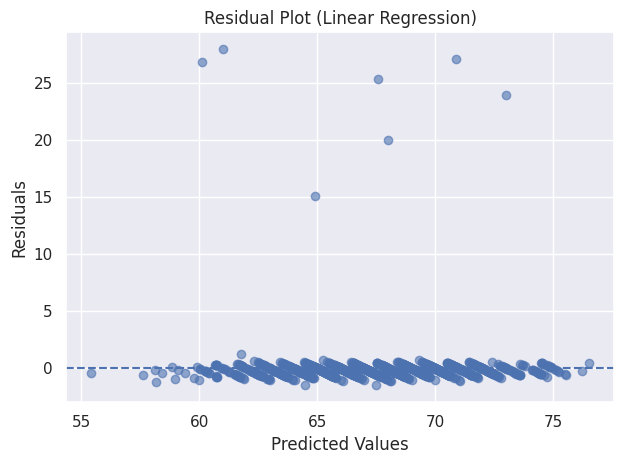

In [16]:
plt.figure()
residuals = y_test_reg - y_pred_lr
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.tight_layout()
plt.show()

### **Interpretation**

* Attendance is the most important factor, making up about $38$% of the model’s total importance.
* Hours studied is the next most important.
* Previous scores (academic history) also have a strong impact.
* Lifestyle factors like physical activity and tutoring matter too, but their effects are smaller.

## **Answer To Research Questions**

### Which factors most strongly influence exam scores?

Attendance ($38$%) and Hours Studied ($24$%) are the strongest predictors, followed by Previous Scores. Behavioral factors consistently outweigh demographic ones.

### Can we accurately predict exam scores using regression models?

Yes. Linear Regression achieved an RMSE of $1.80$, meaning predictions were off by less than $2$ points on average, which is reasonably accurate for this dataset.

### Can we classify students into high vs. low performance?

Yes. Logistic Regression correctly classified students with $98.64$% accuracy, and Random Forest achieved $91.98$%.

### Do behavioral factors have a stronger impact than demographic factors?

Yes. The top features by importance are all behavioral — attendance, study hours, and previous scores — while socioeconomic and demographic variables ranked much lower.

## **Discussion and Conclusion**

### Discussion on Regression Results

* Linear Regression performed better than Random Forest, which suggests that the relationships in the data are mostly linear.
* This also means more complex models do not add much value here.
* The low RMSE (around $1.8$) shows the model makes fairly accurate predictions, with only small errors on average.

### Discussion on Classification Results

* Logistic Regression reached very high accuracy (about $98.64$%).
* This suggests there is a clear separation between high and low performers.
* It also shows the dataset has strong patterns that the model can easily learn.
* Random Forest did worse, which again suggests that extra complexity does not improve this dataset.
 
### Discussion on Other Results

* Attendance and study habits are the main drivers of performance prediction.
* Socioeconomic and demographic factors seem less important compared to behavioral factors.
* Overall, this suggests that student behavior plays a bigger role than demographic background in this dataset.

## **Conclusion and Future Steps**

### Final Conclusions (Quantitative Answers)

* Attendance is the most important predictor, contributing about $38$% of the total feature importance in the Random Forest model.
* Hours studied contributes around $24$% of the model’s predictive power, making it the second most important factor.
* Linear Regression performed better in terms of prediction error, with an RMSE of about $1.80$ compared to $2.23$ for Random Forest. This suggests the linear model fits the data more effectively.
* Logistic Regression also performed very well, reaching about $98.64$% accuracy, while Random Forest reached about $91.98$%, showing strong but slightly weaker performance.

In the Linear Regression model, Hours Studied has a positive coefficient of about $0.29$. This means each extra hour studied is linked to roughly a $0.3$-point increase in exam score, assuming other factors stay the same.

Overall, the results suggest the relationship between the inputs and exam scores is mostly linear. Increases in study time and attendance are linked to proportional increases in performance. Students with higher attendance and stronger previous scores generally receive higher predicted exam scores.

In general, this project shows that relatively simple models can predict student performance well when strong behavioral features are available.

## **Challenges**

* The dataset may be too clean or well-structured, which could lead to very high accuracy and a possible risk of overfitting.
* Several categorical variables had to be encoded, which increased the number of features and overall model complexity.
* There was no separate external dataset for validation, which limits how well the results can be generalized to other populations.

## **Future Improvements**

* Try more advanced models such as Gradient Boosting (XGBoost) and Neural Networks.
* Improve feature engineering by adding interaction terms, such as combining study hours and attendance.
* Use regularization methods like Ridge or Lasso to reduce overfitting.
* Collect more diverse or real-world data to improve generalization.
* Do a deeper error analysis to understand where and why the models make mistakes.

## **Author Contribution**

### **Alex Chen:**

* Data preprocessing
* Regression modeling
* Visualization

### **Kevin Chiang:**

* Classification modeling
* Cross-validation
* Discussion & slides

## **References**

Ayesha Siddiqa. Student Performance Dataset. Kaggle. https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance